In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('unsupervised_data.csv')
df.head(15)

,ID,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6
0,1,-21.904591,-22.659091,12.805995,-46.631935,-34.347081,-21.989738
1,2,-28.662385,68.757081,31.761821,3.982259,-62.876866,-61.838563
2,3,-62.551204,60.909235,8.112918,24.110050,-64.372336,70.681940
3,4,14.428024,-48.326045,-65.576518,76.027549,69.966852,48.023953
4,5,9.780285,-55.643172,-72.737299,74.180123,67.873327,41.128015
5,6,-21.453603,-64.085469,33.531356,-17.798743,-62.545042,-6.037034
6,7,-23.389613,72.374877,30.042893,10.586512,-57.302310,-54.444759
7,8,-72.467072,58.620303,24.677408,23.890282,-87.047284,82.695156
8,9,-20.130895,-41.509514,12.871682,-57.478008,-32.062436,-19.000419
9,10,-54.546410,56.365814,17.826895,33.869223,-85.704456,75.548965


In [3]:
X_train=df.iloc[:,1:].to_numpy()
print(X_train)

[[-21.90459052 -22.65909077  12.80599532 -46.63193454 -34.34708058
  -21.98973763]
 [-28.6623852   68.7570811   31.76182149   3.98225896 -62.87686557
  -61.83856263]
 [-62.55120406  60.90923463   8.11291761  24.1100498  -64.37233589
   70.68194042]
 ...
 [-10.5193655   51.35470206 -45.12963703   1.94184293  13.16236957
  -77.77000929]
 [ 47.12231456 -47.27290614 -47.18462792 -52.90839123 -29.80429118
    2.04282004]
 [-12.18331877  52.25702955 -42.01543172  14.20654525   0.70609201
  -77.29727207]]


In [4]:
l=[]
for i in range(1,11):
    centroids=X_train[:40000:int(np.ceil(40000/i))]
    for j in range(1000):
        b=np.argmin(np.sum((X_train[:,None,:]-centroids)**2,axis=2),axis=1)
        centroids=[np.mean(np.array([X_train[l] for l in range(40000) if b[l]==k]),axis=0) for k in range(i)]
    l.append(np.sum((X_train-np.array(centroids)[np.argmin(np.sum((X_train[:,None,:]-centroids)**2,axis=2),axis=1)])**2)/40000)

In [5]:
print(l)

[np.float64(11857.026274397116), np.float64(8226.522503271983), np.float64(6034.206649980121), np.float64(2559.254957914058), np.float64(2554.604079008565), np.float64(1184.3159057629039), np.float64(1507.2276825332767), np.float64(289.0638041213621), np.float64(284.6161222876641), np.float64(283.4510478877412)]


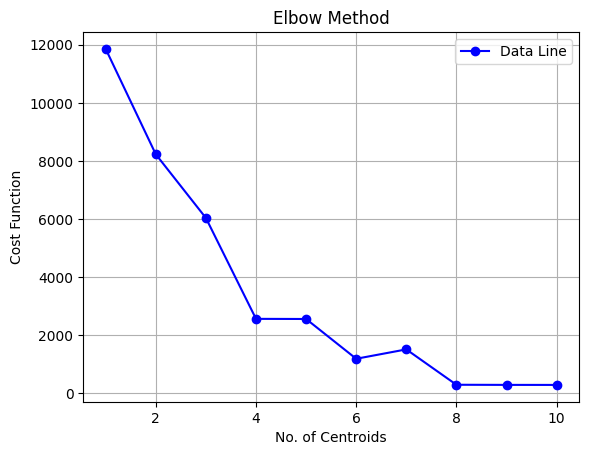

In [6]:
plt.plot(range(1,11),l,marker='o',linestyle='-',color='b',label='Data Line')
plt.xlabel('No. of Centroids')
plt.ylabel('Cost Function')
plt.title('Elbow Method')
plt.grid(True)
plt.legend()
plt.show()